[INFO] Keeping 15 valid frames (norm ≥ 1)
[INFO] Plotting frame 1


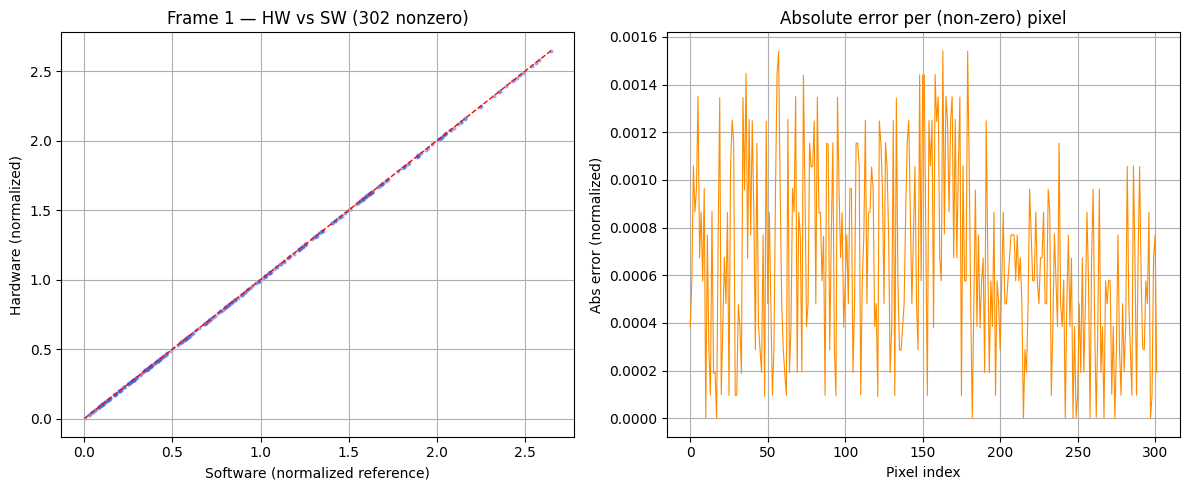

[INFO] Normalized by mean=1.017e-04
[INFO] Mean abs error: 6.591e-04, max: 1.542e-03


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = "output"

# === Load data directly into NumPy ===
def load_csv_fast(path, cols):
    df = pd.read_csv(path, usecols=cols)
    return df.to_numpy()

# Columns: frame, pixel, value
pixels_hw = load_csv_fast(os.path.join(OUTPUT_DIR, "deepwave_sim_hw.csv"), ["frame", "pixel", "value"])
pixels_sw = load_csv_fast(os.path.join(OUTPUT_DIR, "deepwave_sim.csv"), ["frame", "pixel", "value"])

# Columns: frame, norm
norms_hw  = load_csv_fast(os.path.join(OUTPUT_DIR, "deepwave_norms_hw.csv"), ["frame", "norm"])
norms_sw  = load_csv_fast(os.path.join(OUTPUT_DIR, "deepwave_norms.csv"), ["frame", "norm"])

# === Pre-extract ===
frames = np.unique(pixels_hw[:, 0]).astype(int)
pixels_per_frame = np.max(pixels_hw[:, 1].astype(int)) + 1
norms_dict = {int(f): n for f, n in norms_hw}

# === Filter valid frames (norm ≥ 1) ===
valid_frames = np.array([f for f in frames if norms_dict.get(f, 0) >= 1])
print(f"[INFO] Keeping {len(valid_frames)} valid frames (norm ≥ 1)")

# === Choose a frame to plot ===
if len(valid_frames) == 0:
    print("❌ No valid frames with norm ≥ 1.")
else:
    frame_id = valid_frames[0]
    print(f"[INFO] Plotting frame {frame_id}")

    # Slice without Pandas (very fast)
    mask_hw = pixels_hw[:, 0] == frame_id
    mask_sw = pixels_sw[:, 0] == frame_id
    vals_hw = pixels_hw[mask_hw, 2]
    vals_sw = pixels_sw[mask_sw, 2]

    # Remove zero values
    nonzero_mask = (vals_hw != 0) | (vals_sw != 0)
    vals_hw = vals_hw[nonzero_mask]
    vals_sw = vals_sw[nonzero_mask]

    if len(vals_hw) == 0:
        print(f"[Frame {frame_id}] All zeros — skipping.")
    else:
        # === Normalize both arrays by SW mean ===
        mean_sw = np.mean(vals_sw)
        vals_hw /= mean_sw
        vals_sw /= mean_sw

        # Compute errors after normalization
        abs_err = np.abs(vals_hw - vals_sw)
        rel_err = abs_err / np.maximum(np.abs(vals_sw), 1e-12)

        # --- Plot 1: Scatter HW vs SW ---
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.scatter(vals_sw, vals_hw, s=4, alpha=0.4, color='royalblue')
        lim = [min(vals_sw.min(), vals_hw.min()), max(vals_sw.max(), vals_hw.max())]
        plt.plot(lim, lim, 'r--', lw=1)
        plt.xlabel("Software (normalized reference)")
        plt.ylabel("Hardware (normalized)")
        plt.title(f"Frame {frame_id} — HW vs SW ({len(vals_hw)} nonzero)")
        plt.grid(True)

        # --- Plot 2: Absolute error ---
        plt.subplot(1, 2, 2)
        plt.plot(abs_err, lw=0.8, color='darkorange')
        plt.xlabel("Pixel index")
        plt.ylabel("Abs error (normalized)")
        plt.title("Absolute error per (non-zero) pixel")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        print(f"[INFO] Normalized by mean={mean_sw:.3e}")
        print(f"[INFO] Mean abs error: {np.mean(abs_err):.3e}, max: {np.max(abs_err):.3e}")


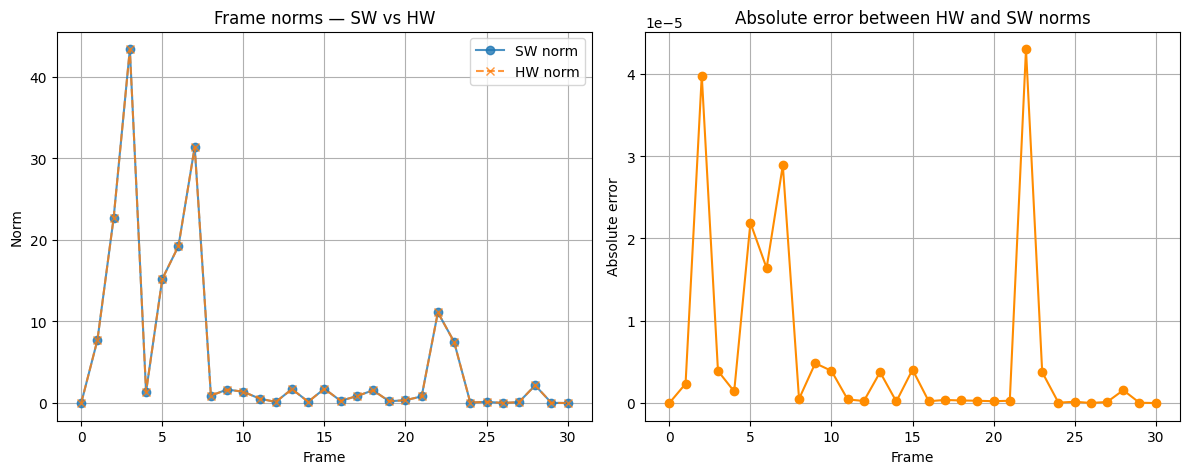

In [4]:
# Plot norms (HW vs SW) and their absolute error per frame
frames_n = norms_sw[:, 0].astype(int)
n_hw = norms_hw[:, 1].astype(float)
n_sw = norms_sw[:, 1].astype(float)
abs_norm_err = np.abs(n_hw - n_sw)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(frames_n, n_sw, marker='o', linestyle='-', label='SW norm', alpha=0.8)
plt.plot(frames_n, n_hw, marker='x', linestyle='--', label='HW norm', alpha=0.8)
plt.xlabel('Frame')
plt.ylabel('Norm')
plt.title('Frame norms — SW vs HW')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(frames_n, abs_norm_err, marker='o', color='darkorange')
plt.xlabel('Frame')
plt.ylabel('Absolute error')
plt.title('Absolute error between HW and SW norms')
plt.grid(True)

plt.tight_layout()
plt.show()